In [4]:
from stock.tw_stock import tw_stock
from stock.update_data import update_data
from stock.plot import plot
from stock.strategy import 選股模式一,雙重金死叉策略,dmi策略,bbi策略,漲幅大於,外陸資連三買超股數,投信連三買超股數
import datetime ,sqlite3
import pandas as pd
from io import StringIO
import numpy as np
update_data=update_data()
plot=plot()

每日股價最新日期(上市): 2022-03-31 00:00:00
每日股價最新日期(上櫃): 2022-03-31 00:00:00
每日股價最新日期(三大法人): 2022-03-31 00:00:00


In [23]:
tw = tw_stock()

start = datetime.datetime(2015, 3, 15)
end = datetime.datetime(2022, 3, 1)

close = tw.get("close", start, end)
open_ = tw.get("open", start, end)
high = tw.get("high", start, end)
low = tw.get("low", start, end)
volume = tw.get("volume", start, end)
法人 = tw.get("三大法人買賣超股數", start, end)

SMA5 = tw.get_均線("SMA", close, 5)
量5 = tw.get_均線("SMA", volume, 5)
量20 = tw.get_均線("SMA", volume, 20)
EMA144 = tw.get_均線("EMA", close, 144)
bbi短 = (tw.get_均線("SMA", close, 8) + tw.get_均線("SMA", close, 13) + tw.get_均線("SMA", close, 21) + tw.get_均線("SMA", close, 34)) / 4
bbi長 = (tw.get_均線("SMA", close, 55) + tw.get_均線("SMA", close, 89) + tw.get_均線("SMA", close, 144) + tw.get_均線("SMA", close, 233)) / 4

K, D = tw.get_technical_index("KD", close, open_, high, low, volume)
快MACD, 慢MACD, _ = tw.get_technical_index("MACD", close, open_, high, low, volume)
OBV = tw.get_technical_index("OBV", close, open_, high, low, volume)
OBV_EMA = tw.get_均線("EMA", OBV, 144)
PLUS_DI = tw.get_technical_index("PLUS_DI", close, open_, high, low, volume)
MINUS_DI = tw.get_technical_index("MINUS_DI", close, open_, high, low, volume)
ADX = tw.get_technical_index("ADX", close, open_, high, low, volume)

In [6]:
def 評估停利停損(buy_price, future_prices, take_profit=0.1, stop_loss=-0.05):
    for i, price in enumerate(future_prices):
        pct_change = (price - buy_price) / buy_price
        if pct_change >= take_profit:
            return "勝利", pct_change, i + 1
        elif pct_change <= stop_loss:
            return "失敗", pct_change, i + 1
    return "未達標", (future_prices[-1] - buy_price) / buy_price, len(future_prices)


In [24]:
策略列表 = {
    "策略一": lambda x: 選股模式一(close, open_, high, volume, SMA5, 量5, 法人, x),
    "雙重金死叉": lambda x: 雙重金死叉策略(close, K, D, 快MACD, 慢MACD, x),
    "dmi策略": lambda x: dmi策略(close, low, OBV, OBV_EMA, EMA144, MINUS_DI, PLUS_DI, ADX, x),
    "bbi策略": lambda x: bbi策略(close, bbi短, bbi長, high, low, 量5, 量20, x)
}

觀察天數 = 5
停利 = 0.10
停損 = -0.05

backtest_all = []

for i in range(250, len(close) - 觀察天數):  # 前面250天預留技術指標
    for 策略名, 策略函數 in 策略列表.items():
        try:
            res = 策略函數(i)
            buy_date = res["date"]
            for stock in res["stocks"]:
                buy_price = close.iloc[i][stock]
                future_prices = close.iloc[i+1:i+1+觀察天數][stock].values
                if any(pd.isna(future_prices)) or pd.isna(buy_price):
                    continue
                outcome, pct, hold = 評估停利停損(buy_price, future_prices, 停利, 停損)
                backtest_all.append({
                    "策略": 策略名,
                    "日期": buy_date,
                    "股票": stock,
                    "買進價": buy_price,
                    "結果": outcome,
                    "報酬率": round(pct * 100, 2),
                    "持有天數": hold
                })
        except Exception as e:
            continue


2016-03-22 00:00:00符合選股模式一的股票有0檔股票,包括:[]
2016-03-22 00:00:00符合雙重金死叉策略的股票有0檔股票,包括:[]
2016-03-22 00:00:00符合dmi策略的股票有212檔股票,包括:['006206' '006207' '00639' '00643' '01002T' '1108' '1201' '1217' '1234'
 '1236' '1303' '1307' '1312' '1321' '1340' '1402' '1409' '1414' '1423'
 '1432' '1434' '1444' '1447' '1451' '1454' '1455' '1457' '1459' '1464'
 '1465' '1473' '1506' '1512' '1513' '1531' '1535' '1540' '1589' '1608'
 '1611' '1720' '1722' '1723' '1725' '1729' '1731' '1732' '1734' '1736'
 '1902' '1907' '2002' '2006' '2009' '2012' '2013' '2014' '2030' '2101'
 '2108' '2109' '2114' '2201' '2207' '2208' '2303' '2313' '2316' '2324'
 '2342' '2347' '2357' '2359' '2363' '2367' '2373' '2390' '2401' '2433'
 '2437' '2480' '2482' '2483' '2484' '2485' '2495' '2497' '2504' '2506'
 '2509' '2514' '2515' '2530' '2538' '2547' '2548' '2601' '2607' '2609'
 '2610' '2615' '2617' '2637' '2702' '2731' '2812' '2816' '2832' '2841'
 '2845' '2855' '2856' '2883' '2885' '2904' '2905' '2906' '2911' '2923'
 '3011' '3016' '3017' '

In [29]:
result_df = pd.DataFrame(backtest_all)
print(result_df) 
result_df.to_csv("回測結果.csv", index=False)

           策略         日期      股票    買進價   結果   報酬率  持有天數
0       dmi策略 2016-03-22  006206  26.77  未達標 -3.32     5
1       dmi策略 2016-03-22  006207  21.13  未達標 -3.17     5
2       dmi策略 2016-03-22   00639  10.38  未達標 -3.85     5
3       dmi策略 2016-03-22   00643  16.55  未達標 -3.14     5
4       dmi策略 2016-03-22  01002T  17.10  未達標  0.23     5
...       ...        ...     ...    ...  ...   ...   ...
142191  雙重金死叉 2022-02-18    3224  53.30  未達標 -0.56     5
142192  雙重金死叉 2022-02-18    3289  50.10  未達標 -3.89     5
142193  雙重金死叉 2022-02-18    4526  16.50  未達標  1.82     5
142194  雙重金死叉 2022-02-18    8066  33.80  未達標 -0.89     5
142195  雙重金死叉 2022-02-18    8176   8.65  未達標 -1.50     5

[142196 rows x 7 columns]


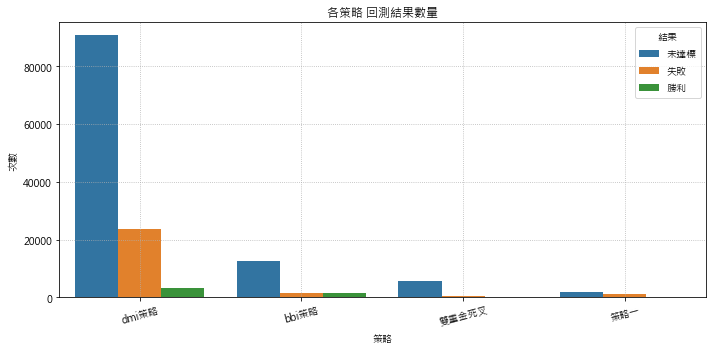

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # 微軟正黑體
plt.rcParams['axes.unicode_minus'] = False          # 正負號正常顯示

# === 圖1：各策略 勝/敗/未達標 次數 ===
plt.figure(figsize=(10, 5))
sns.countplot(data=result_df, x='策略', hue='結果')
plt.title("各策略 回測結果數量")
plt.ylabel("次數")
plt.xticks(rotation=15)
plt.grid(True, linestyle='dotted')
plt.tight_layout()
plt.show()


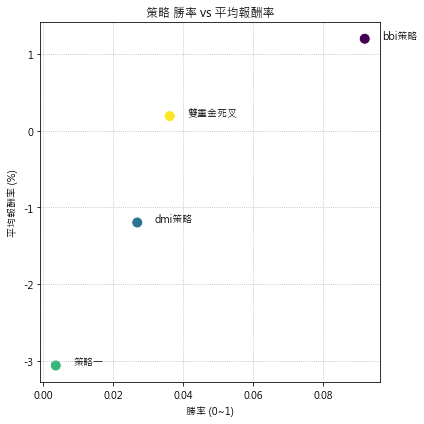

In [28]:

# === 圖3：策略 平均報酬 vs 勝率 ===
summary = result_df.groupby('策略').apply(lambda g: pd.Series({
    '平均報酬率': g['報酬率'].mean(),
    '勝率': (g['結果'] == '勝利').sum() / len(g)
})).reset_index()

plt.figure(figsize=(6, 6))
sns.scatterplot(data=summary, x='勝率', y='平均報酬率', s=120)
for _, row in summary.iterrows():
    plt.text(row['勝率'] + 0.005, row['平均報酬率'], row['策略'], fontsize=10)
plt.title("策略 勝率 vs 平均報酬率")
plt.xlabel("勝率 (0~1)")
plt.ylabel("平均報酬率 (%)")
plt.grid(True, linestyle='dotted')
plt.tight_layout()
plt.show()
